# 02 — Cross-Sectional Momentum Research (Example)

**Research question**: Can cross-sectional momentum generate stable
out-of-sample risk-adjusted returns across liquid multi-asset ETFs after
transaction costs and volatility targeting?

**Universe**: SPY, QQQ, IWM, EFA, EEM, TLT, GLD, VNQ — US large/small
cap, developed/emerging ex-US equities, long treasuries, gold, real estate.

**Signal**: 12-month return excluding the most recent month (standard
momentum construction to avoid short-term reversal), ranked cross-sectionally
each month; long the top half.

**Hypothesis** (H1): after realistic transaction costs and out-of-sample
validation, the strategy delivers a positive risk-adjusted return (Sharpe > 0)
that is reasonably stable across sub-periods.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

from quantlab.config import ExperimentConfig
from quantlab.data.loader import DataLoader
from quantlab.backtesting.runner import run_backtest_from_config

config = ExperimentConfig.from_yaml("../configs/momentum_sp500.yaml")
data, report = DataLoader().load(config)
len(data), report.row_count


(36232, 36232)

## Run the backtest

In [2]:
result = run_backtest_from_config(data, config, data_quality_report=report)
print(result.summary())


Experiment : cross_sectional_momentum_etfs
Strategy   : cross_sectional_momentum
Symbols    : SPY, QQQ, IWM, EFA, EEM, TLT, GLD, VNQ
Period     : 2008-01-02 -> 2025-12-31
------------------------------------------------
Total return       :    172.95%
CAGR               :      5.75%
Volatility (ann.)  :      9.00%
Sharpe             :       0.44
Sortino            :       0.62
Calmar             :       0.36
Max drawdown       :    -15.82%
Hit rate (non-zero periods): 54.55%
Total costs (currency units): 5938.76
Number of trades   :        277
------------------------------------------------
Beta               :       0.25
Alpha (ann.)       :      1.40%
Information ratio  :      -0.39


## Equity curve vs benchmark

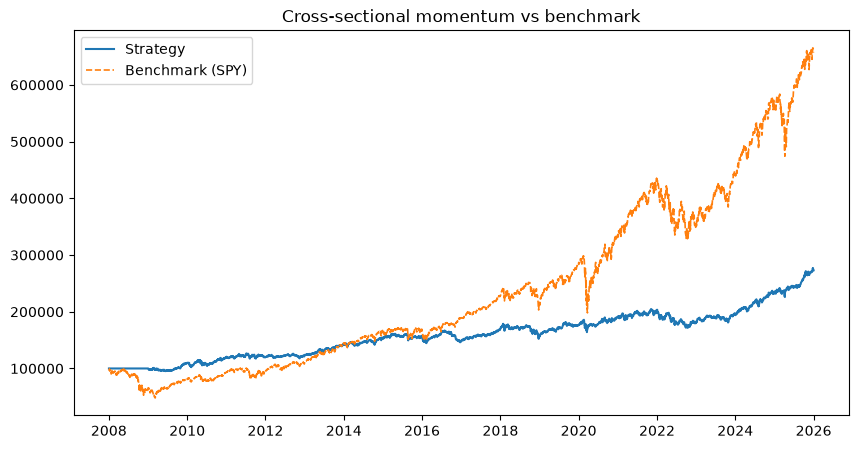

In [3]:
equity = result.equity_curve
benchmark_returns = result.benchmark_returns

if benchmark_returns is None:
    raise RuntimeError("No benchmark returns are available for this backtest.")

bench_equity = float(equity.iloc[0]) * (1 + benchmark_returns).cumprod()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(equity.index, equity.to_numpy(dtype=float), label="Strategy", lw=1.5)
ax.plot(bench_equity.index, bench_equity.to_numpy(dtype=float), label=f"Benchmark ({config.benchmark_label})", lw=1.2, ls="--")
ax.set_title("Cross-sectional momentum vs benchmark")
ax.legend()
plt.show()


## Performance by year

In [4]:
from quantlab.reporting.tables import subperiod_table
table = subperiod_table(result)
table


,Period,Return,CAGR,Sharpe,Max Drawdown,Volatility,Turnover (x),Number of Trades
0,Full sample,1.729543,0.057462,0.443716,-0.158208,0.089985,67.055796,277
1,2008,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
2,2009,0.092668,0.092668,0.801381,-0.056493,0.090761,1.801406,15
3,2010,0.093298,0.093298,0.615134,-0.091070,0.125198,4.190302,28
4,2011,0.004023,0.004023,-0.109156,-0.073369,0.100413,6.713500,25
5,2012,0.020651,0.020817,0.041289,-0.065115,0.063776,3.600000,12
6,2013,0.168489,0.168489,1.773823,-0.043644,0.078258,6.600000,22
7,2014,0.067877,0.067877,0.611583,-0.057080,0.079898,3.000000,10
8,2015,0.020909,0.020909,0.049578,-0.072616,0.082531,4.800000,16
9,2016,-0.050045,-0.050045,-0.820584,-0.124595,0.082768,4.800000,16


## Out-of-sample validation (walk-forward)

Parameters are selected on a validation block and only then evaluated on an
untouched test block — the test period is never used to choose
`lookback_period`, `skip_period` or `top_fraction`. The notebook calls the same
configured-or-default grid helper as the CLI, so both interfaces evaluate
identical candidates.


In [5]:
from quantlab.validation import WalkForwardValidator, parameter_grid_for_config

train_window = config.validation.train_window or 500
validation_window = config.validation.validation_window or 126
test_window = config.validation.test_window or 126

validator = WalkForwardValidator(config)
wf = validator.run(
    data,
    parameter_grid=parameter_grid_for_config(config),
    train_window=train_window,
    validation_window=validation_window,
    test_window=test_window,
    expanding=config.validation.expanding,
)
print(f"{len(wf.folds)} walk-forward folds")
wf.summary_table()


26 walk-forward folds


,fold,param_lookback_period,param_skip_period,validation_score,test_return,test_sharpe
0,0,189,21,0.407720,0.002839,-0.133096
1,1,252,21,0.377440,0.086610,2.145034
2,2,252,21,1.499158,0.033276,0.583157
3,3,126,21,1.792590,0.037070,1.118928
4,4,189,21,1.279034,0.008293,-0.007815
5,5,189,21,1.389653,-0.043895,-0.978858
6,6,252,21,-0.151705,0.065673,1.240997
7,7,126,21,0.271631,-0.050807,-1.400648
8,8,126,0,0.805464,0.052652,1.356497
9,9,189,21,1.404681,0.079879,2.206585


In [6]:
oos_metrics = wf.oos_metrics(config.periods_per_year, config.risk_free_rate)
print(f"Out-of-sample Sharpe: {oos_metrics.get('sharpe_ratio', 0):.2f}")
print(f"Out-of-sample CAGR:   {oos_metrics.get('cagr', 0):.2%}")
print(f"Parameter stability (coefficient of variation): {wf.parameter_stability()}")


Out-of-sample Sharpe: 0.32
Out-of-sample CAGR:   4.69%
Parameter stability (coefficient of variation): {'lookback_period': 0.23018039969328674, 'skip_period': 0.6666666666666667}


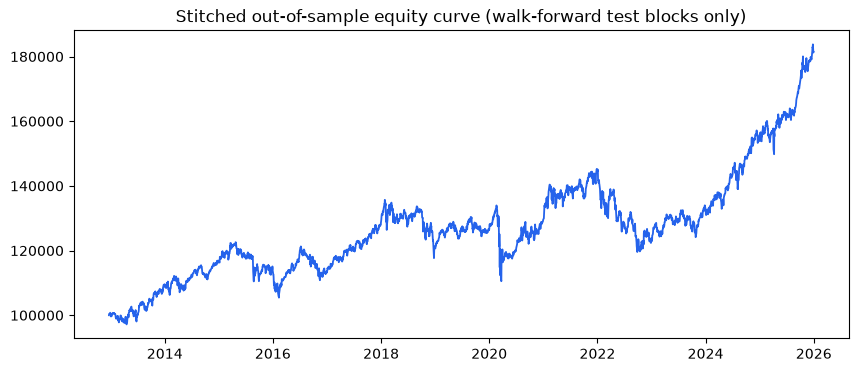

In [7]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wf.oos_equity.index, wf.oos_equity.to_numpy(dtype=float), color="#2563eb", lw=1.3)
ax.set_title("Stitched out-of-sample equity curve (walk-forward test blocks only)")
plt.show()


## Conclusion

The strategy's full-sample and walk-forward out-of-sample Sharpe ratios are
relatively close, which provides some reassurance against severe overfitting.
However, the observed risk-adjusted performance remains modest and does not
demonstrate a persistent ability to outperform the market. These results are
historical, depend on the stated assumptions and execution costs, and do not
guarantee future performance.
